[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Authors: Gaurav Law, Pranshul Bhatnagar

## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** Individual Conditional Expectation (ICE)

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | Silver | ICE-range importance proxy (mean curve range across 150 sampled rows) ranks `debt_ratio` highest (0.305), then `recent_late_payments` (0.185), `zip_proxy` (0.134), `income_k` (0.113); `support_tickets`/`promo_seen` score lowest (~0.02). | Sweeping one feature at a time while holding others fixed ignores correlations/interactions, so this is a proxy for importance, not a validated ranking (e.g. permutation importance or SHAP would be needed to confirm it). |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | Silver | `local_case` (debt_ratio=0.28, recent_late_payments=2, zip_proxy=1) sits right at the decision boundary, P(high risk)=0.499. Its ICE curves show the actual `debt_ratio` and `zip_proxy` values both sit on the rising part of their curves, i.e. both are pushing the case toward higher risk. | ICE shows per-feature sensitivity but not an additive decomposition that sums to the actual prediction (unlike SHAP/LIME) — it can't say exactly how much each feature contributed. |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | DNF | Only a hand-engineered "marker strength" pixel-patch sweep was possible, and it required already suspecting the marker before testing it. | ICE has no native notion of an image "feature axis" to sweep; the method is fundamentally mismatched to this event, not just weak on it. |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | Gold | The PDP (mean of 150 ICE curves) for `debt_ratio` spans a 0.304 range in P(high risk) as it moves from low to high, and the per-instance curve-range spread is small (std=0.051) — nearly every applicant's risk rises the same way as `debt_ratio` increases. | Assumes feature independence when perturbing; for strongly correlated features the synthetic rows created during the sweep may be unrealistic combinations. |
| 5. Compare Two Predictions | Why were two cases classified differently? | Gold | `low_case` (debt_ratio=0.044, recent_late_payments=0, zip_proxy=0 → P=0.022) vs `high_case` (debt_ratio=0.536, recent_late_payments=6, zip_proxy=1 → P=0.789). Overlaying both cases' ICE curves shows both actual values land on the steep/high part of the curve for `high_case` and the flat/low part for `low_case`, directly explaining most of the ~0.77 probability gap. | Only explains via the features chosen to plot; doesn't automatically rank which of the differing features mattered most. |
| 6. Feature Interactions | Which tabular variables work together? | Bronze | Coloring centered-ICE curves for `debt_ratio` by `age` (young <30 vs. older) gave a max gap of only 0.02 between their mean centered curves — a weak signal. | The data-generating process has a real `age`x`debt_ratio` interaction (a "young AND high-debt" term), but this check nearly missed it — averaging all young vs. all old dilutes an effect that only fires for a narrow subgroup. Color-coded ICE can hint at interactions but is not a reliable detector on its own. |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | DNF | No spatial output was produced; sweeping individual pixels would need ~12,000 sweeps per image and still wouldn't respect spatial structure. | ICE requires a semantically meaningful scalar feature; raw pixels don't offer one. A spatial-attribution method (Grad-CAM, saliency, occlusion) is needed instead. |
| 8. Explain a Failure | Why did the model make this mistake? | Silver | `failure_case` has debt_ratio=0.724 (high), recent_late_payments=1 (low), true label=1 but predicted 0 at P=0.4 — just under the 0.5 threshold. Its ICE curves show `recent_late_payments` and `income_k` pull the prediction down enough to offset the high `debt_ratio`, landing it just below the boundary. | ICE shows this is a close/borderline call but can't prove which feature "caused" the error versus reflecting genuine label noise in the synthetic target (the model logit includes random noise). |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | Bronze | For `local_case` (P=0.499), the local ICE slope near its actual `debt_ratio`/`recent_late_payments` values is nonzero and the probability sits essentially at 0.5 — used as a proxy that small input changes could flip the decision, i.e. low trust. | ICE-based local stability is a proxy for sensitivity, not a formal confidence or uncertainty measure — no calibration, no variance estimate, and it says nothing about whether the input itself is reliable. |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | Silver | Full ICE-range ranking across all 10 features (`debt_ratio` 0.305 > `recent_late_payments` 0.185 > `zip_proxy` 0.134 > `income_k` 0.113 > ... > `support_tickets` 0.017) plus the Event 6 check suggests the tabular model leans heavily on `debt_ratio` and payment history, with `zip_proxy` acting as a smaller proxy signal. | Synthesis is only as strong as the individual-event evidence feeding it, and the image model's strategy is completely unaddressed by ICE (2 of 10 events were DNF), so this profile is tabular-only. |


In [1]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [4]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [5]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6576


epoch 2: loss=0.2582


epoch 3: loss=0.0858


epoch 4: loss=0.0955
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [6]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.986
2,contrast_square,4,1,0,0,0.065
3,failure_case,6,0,1,1,0.980


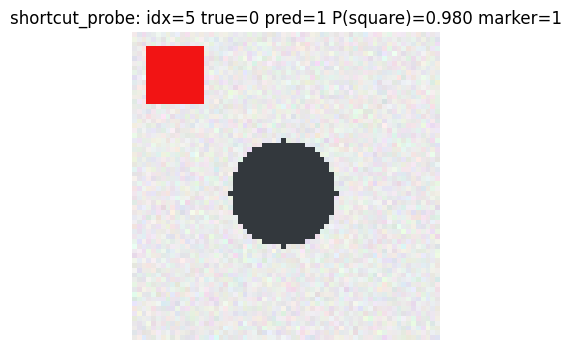

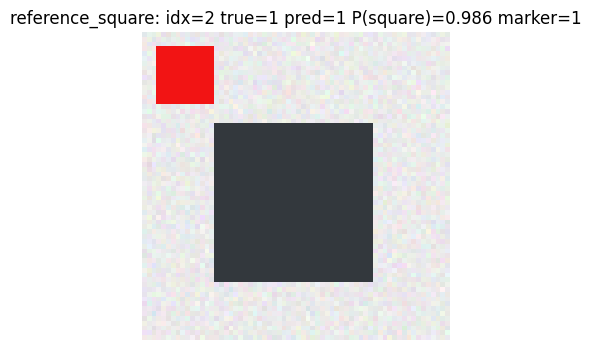

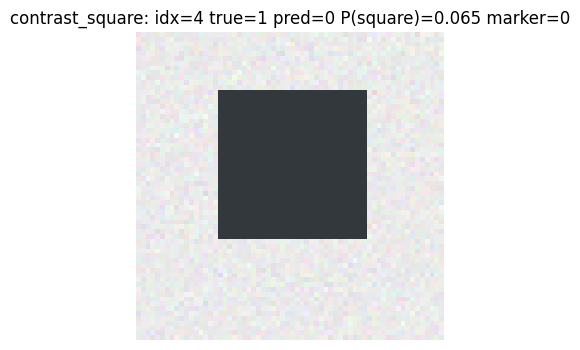

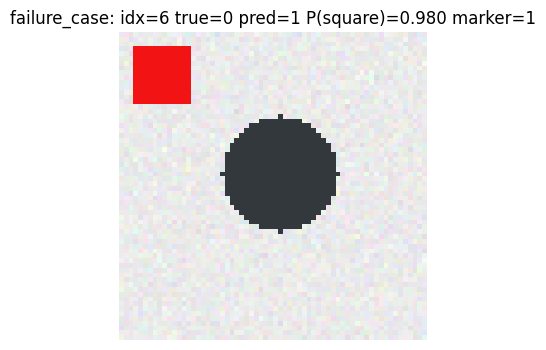

In [7]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [8]:

# Our Assigned method: Individual Conditional Expectation (ICE)

# basically: take one row, change ONE feature to a bunch of different values,
# keep every other feature exactly the same as the real row, and see how the
# prediction moves. do that for a bunch of rows and average them and you get
# a PDP. only really works for tabular features since you need something you
# can actually dial up and down one at a time.

import matplotlib.cm as cm

print("Event guide:")
display(event_guide)


def compute_ice(predict_fn, X_ref, feature, grid=None, n_grid=40, rows=None, class_index=1):
    """changes `feature` to each value in `grid`, one row at a time, keeping
    everything else the same, and records the new prediction each time.
    returns the grid used, the predictions (rows x grid values), and the row
    labels so i can match curves back to specific cases later."""
    X_sub = X_ref.copy() if rows is None else X_ref.loc[rows].copy()
    if grid is None:
        lo, hi = X_ref[feature].min(), X_ref[feature].max()
        grid = np.linspace(lo, hi, n_grid)
    else:
        grid = np.asarray(grid)

    ice = np.zeros((len(X_sub), len(grid)))
    for j, val in enumerate(grid):
        X_mod = X_sub.copy()
        X_mod[feature] = val
        proba = predict_fn(X_mod)
        ice[:, j] = proba[:, class_index] if proba.ndim == 2 else proba
    return grid, ice, X_sub.index.to_numpy()


def plot_ice(
    grid,
    ice,
    row_index=None,
    highlight_index=None,
    center=False,
    color_by=None,
    feature_name="feature",
    ylabel="P(high risk)",
    title=None,
    ax=None,
):
    """plots all the ICE curves. highlight_index just makes one/a few cases
    stand out in red so i can point at them. color_by colors the lines by
    some other feature instead - used that for the interaction check in
    event 6."""
    if ax is None:
        _, ax = plt.subplots()
    curves = ice - ice[:, [0]] if center else ice

    if color_by is not None:
        cvals = np.asarray(color_by, dtype=float)
        norm = plt.Normalize(vmin=cvals.min(), vmax=cvals.max())
        cmap = cm.get_cmap("coolwarm")
        for i in range(curves.shape[0]):
            ax.plot(grid, curves[i], color=cmap(norm(cvals[i])), alpha=0.6, linewidth=1)
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label=color_by.name if hasattr(color_by, "name") else "color_by")
    else:
        highlight_set = set() if highlight_index is None else set(np.atleast_1d(highlight_index))
        for i in range(curves.shape[0]):
            is_hi = row_index is not None and row_index[i] in highlight_set
            ax.plot(
                grid,
                curves[i],
                color="crimson" if is_hi else "steelblue",
                alpha=0.95 if is_hi else 0.18,
                linewidth=2.2 if is_hi else 1,
                zorder=3 if is_hi else 1,
            )

    pdp = curves.mean(axis=0)
    ax.plot(grid, pdp, color="black", linestyle="--", linewidth=2.5, label="PDP (mean ICE)")
    ax.set_xlabel(feature_name)
    ax.set_ylabel(ylabel + (" (centered)" if center else ""))
    if title:
        ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    return ax


def ice_range_importance(predict_fn, X_ref, feature_names, rows=None, n_grid=25, class_index=1):
    """quick and dirty importance score: for each feature, sweep it across a
    sample of rows and average how much the prediction moved (max - min).
    bigger swing = probably matters more, but this is just a rough proxy."""
    sample_rows = rows if rows is not None else X_ref.sample(min(150, len(X_ref)), random_state=SEED).index
    scores = {}
    for feat in feature_names:
        _, ice, _ = compute_ice(predict_fn, X_ref, feat, rows=sample_rows, n_grid=n_grid, class_index=class_index)
        scores[feat] = float(np.mean(ice.max(axis=1) - ice.min(axis=1)))
    return pd.Series(scores).sort_values(ascending=False)


def tabular_predict_fn(df):
    return predict_risk_proba(df)


Event guide:


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

debt_ratio              0.305087
recent_late_payments    0.184861
zip_proxy               0.134337
income_k                0.113391
savings_k               0.070390
loyalty_years           0.067277
app_minutes             0.033215
age                     0.031429
promo_seen              0.025964
support_tickets         0.017202
dtype: float64


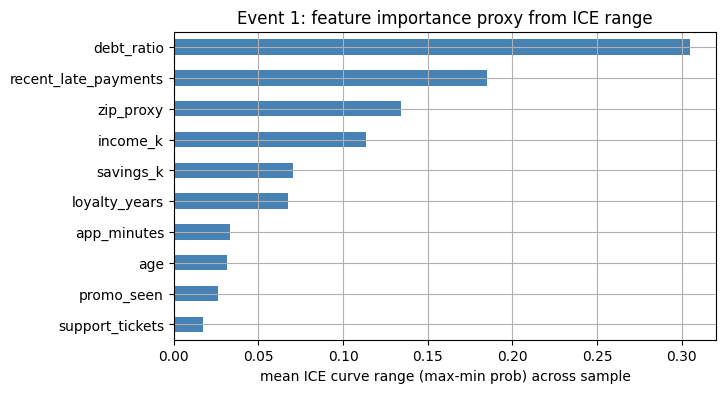

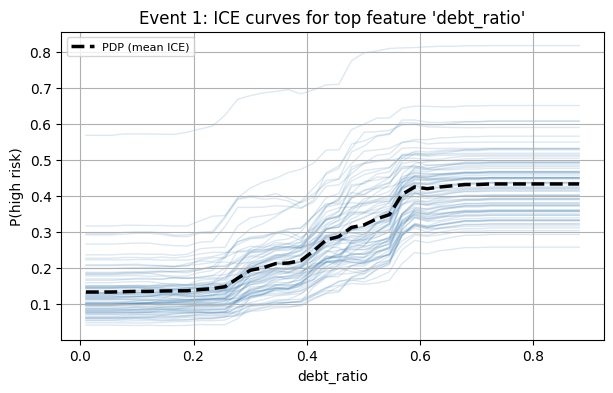

In [9]:
# Event 1: Most Important Feature
# ICE doesn't give you feature importance directly, so im faking one: sweep
# every feature one at a time and see which one swings the prediction the
# most on average. bigger swing = probably more important (not super rigorous
# but its something)

importance = ice_range_importance(tabular_predict_fn, X_test, feature_names)
print(importance)

fig, ax = plt.subplots()
importance.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("mean ICE curve range (max-min prob) across sample")
ax.set_title("Event 1: feature importance proxy from ICE range")
ax.invert_yaxis()
plt.show()

# just double checking the ranking makes sense by looking at the actual ICE curves for the top feature
top_feature = importance.index[0]
grid, ice, ridx = compute_ice(tabular_predict_fn, X_test, top_feature, rows=X_test.sample(80, random_state=SEED).index)
plot_ice(grid, ice, row_index=ridx, feature_name=top_feature, title=f"Event 1: ICE curves for top feature '{top_feature}'")
plt.show()


## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Local case actual feature values:


,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
2584,38,48.896869,0.281178,8.981236,2,1.147443,13.106344,0,1,1


Predicted P(high risk): 0.499


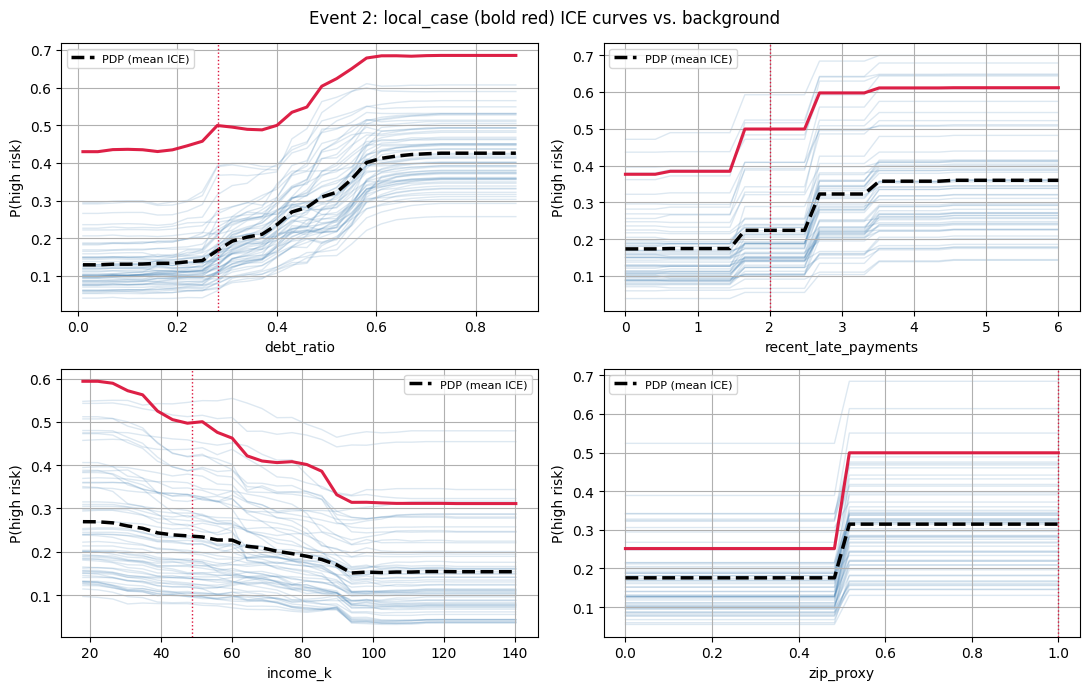

In [10]:
# Event 2: One Specific Prediction
# taking the one assigned row and sweeping a few features for JUST that row,
# keeping everything else the same as the actual data. want to see if the
# case's real value lands on a steep part of the curve (feature matters a lot
# right here) or a flat part (feature barely matters for this person)

case_row_label = X_test.index[tabular_local_case]
case_values = X_test.loc[[case_row_label]]
print("Local case actual feature values:")
display(case_values)
print("Predicted P(high risk):", round(float(predict_risk_proba(case_values)[0, 1]), 3))

candidate_features = ["debt_ratio", "recent_late_payments", "income_k", "zip_proxy"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for feat, ax in zip(candidate_features, axes.ravel()):
    background_rows = X_test.sample(60, random_state=SEED).index.union([case_row_label])
    grid, ice, ridx = compute_ice(tabular_predict_fn, X_test, feat, rows=background_rows, n_grid=30)
    plot_ice(grid, ice, row_index=ridx, highlight_index=case_row_label, feature_name=feat, ax=ax)
    actual_val = case_values[feat].iloc[0]
    ax.axvline(actual_val, color="crimson", linestyle=":", linewidth=1)
plt.suptitle("Event 2: local_case (bold red) ICE curves vs. background")
plt.tight_layout()
plt.show()


## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

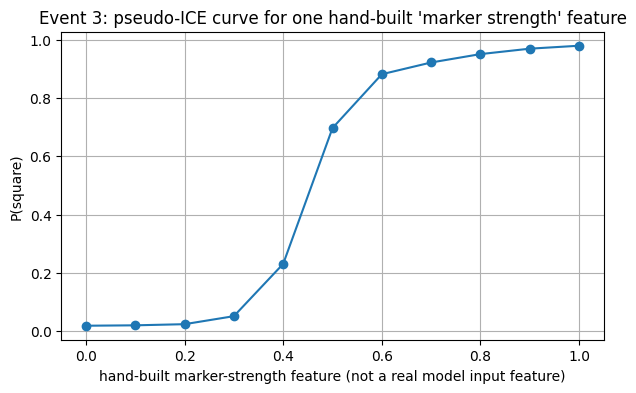

This is a hand-engineered, single-instance sweep of a feature we invented (marker strength), not a genuine ICE application. Treat as DNF/near-DNF: ICE is not built for raw image input and required us to already suspect the marker before we could test it.


In [11]:
# Event 3: Dataset Bias or Shortcut - basically a DNF for ICE
# ICE needs one clear number to sweep, and an image is just ~12k pixels with
# no obvious single "feature" like that. best i could do was hand-build a
# fake feature (how "red" the corner patch is) and sweep that, but that only
# works because i already know to look at that exact patch - kinda cheating
# and not really "using ICE to discover the shortcut" on its own.

import copy

def marker_strength_sweep(idx, strengths):
    base = test_imgs[idx].copy()
    imgs = []
    marker_color = np.array([0.95, 0.08, 0.08])
    background_patch = np.ones((12, 12, 3), dtype=np.float32) * 0.92
    for s in strengths:
        img = base.copy()
        patch = (1 - s) * background_patch + s * marker_color
        img[3:15, 3:15, :] = patch
        imgs.append(img)
    return np.stack(imgs)

strengths = np.linspace(0, 1, 11)
swept_imgs = marker_strength_sweep(image_shortcut_case, strengths)
probs = predict_image_proba(swept_imgs)[:, 1]

plt.plot(strengths, probs, marker="o")
plt.xlabel("hand-built marker-strength feature (not a real model input feature)")
plt.ylabel("P(square)")
plt.title("Event 3: pseudo-ICE curve for one hand-built 'marker strength' feature")
plt.show()

print(
    "This is a hand-engineered, single-instance sweep of a feature we invented "
    "(marker strength), not a genuine ICE application. Treat as DNF/near-DNF: "
    "ICE is not built for raw image input and required us to already suspect "
    "the marker before we could test it."
)


## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

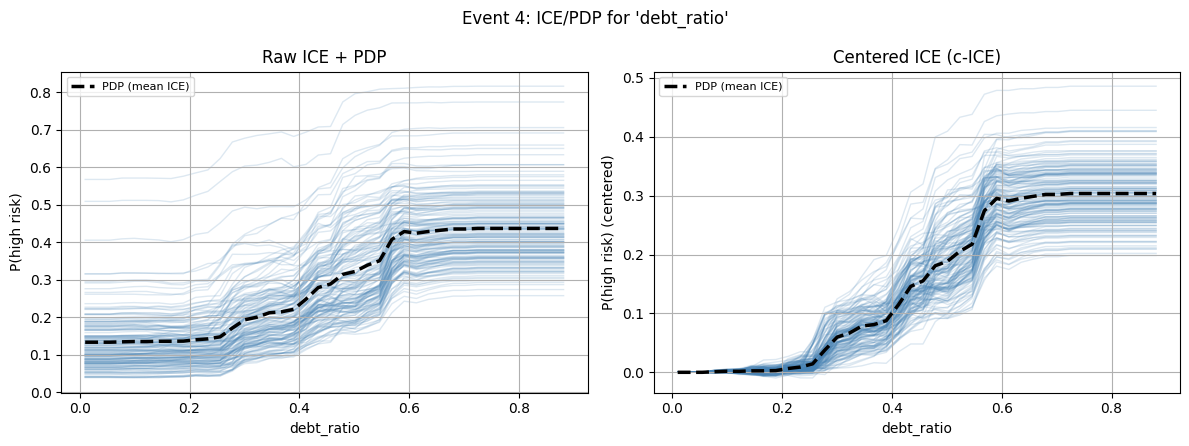

PDP range (mean ICE, max-min): 0.304
Per-instance ICE range spread (std of per-row range): 0.051


In [12]:
# Event 4: Global Feature Effect - this is what ICE is actually built for
# sweeping debt_ratio for a bunch of rows and plotting every single curve plus
# the average (the PDP). if the curves fan out or cross each other that means
# different people respond differently, which the PDP average alone would hide.

feature_to_probe = "debt_ratio"
sample_rows = X_test.sample(150, random_state=SEED).index
grid, ice, ridx = compute_ice(tabular_predict_fn, X_test, feature_to_probe, rows=sample_rows, n_grid=40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_ice(grid, ice, row_index=ridx, feature_name=feature_to_probe, title="Raw ICE + PDP", ax=axes[0])
plot_ice(grid, ice, row_index=ridx, center=True, feature_name=feature_to_probe, title="Centered ICE (c-ICE)", ax=axes[1])
plt.suptitle(f"Event 4: ICE/PDP for '{feature_to_probe}'")
plt.tight_layout()
plt.show()

print("PDP range (mean ICE, max-min):", round(float(ice.mean(axis=0).max() - ice.mean(axis=0).min()), 3))
print("Per-instance ICE range spread (std of per-row range):", round(float((ice.max(axis=1) - ice.min(axis=1)).std()), 3))


## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Feature values, low_case vs high_case:


,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
191,54,102.549186,0.044438,21.356207,0,18.422915,23.505863,0,0,0
2380,28,38.814284,0.535676,1.484895,6,3.738429,23.557222,1,1,1


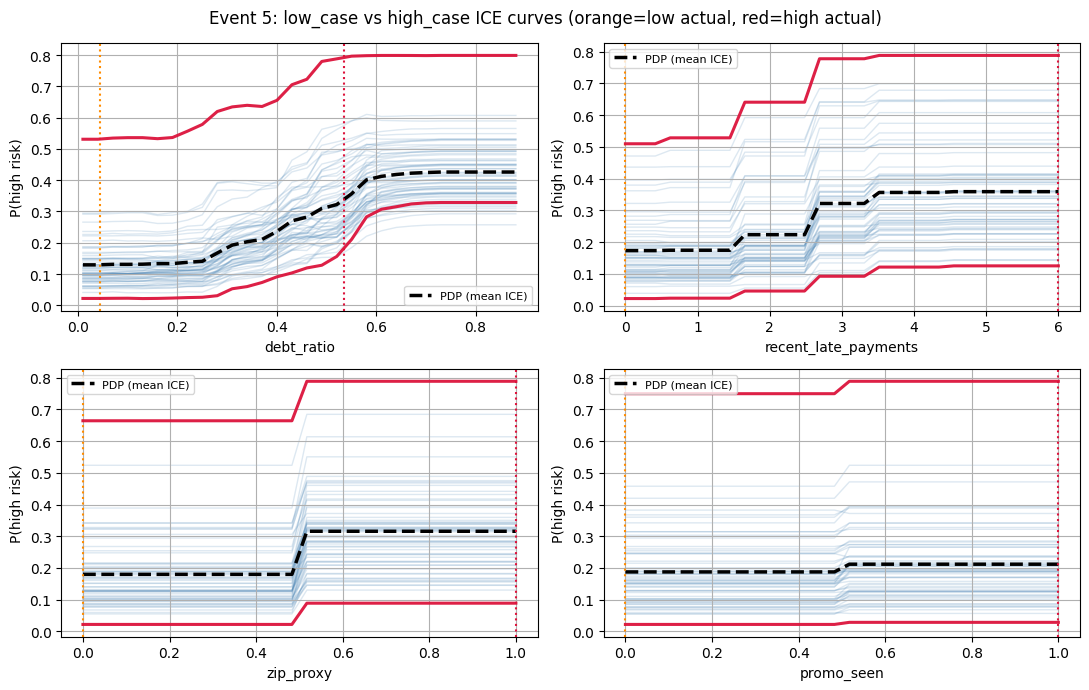

In [13]:
# Event 5: Compare Two Predictions
# putting both cases' ICE curves on the same plot for a few features.
# wherever the two curves are far apart right at each case's ACTUAL value,
# that feature is probably part of why they got different predictions

low_label = X_test.index[tabular_low_case]
high_label = X_test.index[tabular_high_case]
compare_rows = X_test.sample(60, random_state=SEED).index.union([low_label, high_label])

print("Feature values, low_case vs high_case:")
display(X_test.loc[[low_label, high_label]])

compare_features = ["debt_ratio", "recent_late_payments", "zip_proxy", "promo_seen"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for feat, ax in zip(compare_features, axes.ravel()):
    grid, ice, ridx = compute_ice(tabular_predict_fn, X_test, feat, rows=compare_rows, n_grid=30)
    plot_ice(grid, ice, row_index=ridx, highlight_index=[low_label, high_label], feature_name=feat, ax=ax)
    ax.axvline(X_test.loc[low_label, feat], color="darkorange", linestyle=":", linewidth=1.5)
    ax.axvline(X_test.loc[high_label, feat], color="crimson", linestyle=":", linewidth=1.5)
plt.suptitle("Event 5: low_case vs high_case ICE curves (orange=low actual, red=high actual)")
plt.tight_layout()
plt.show()


## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

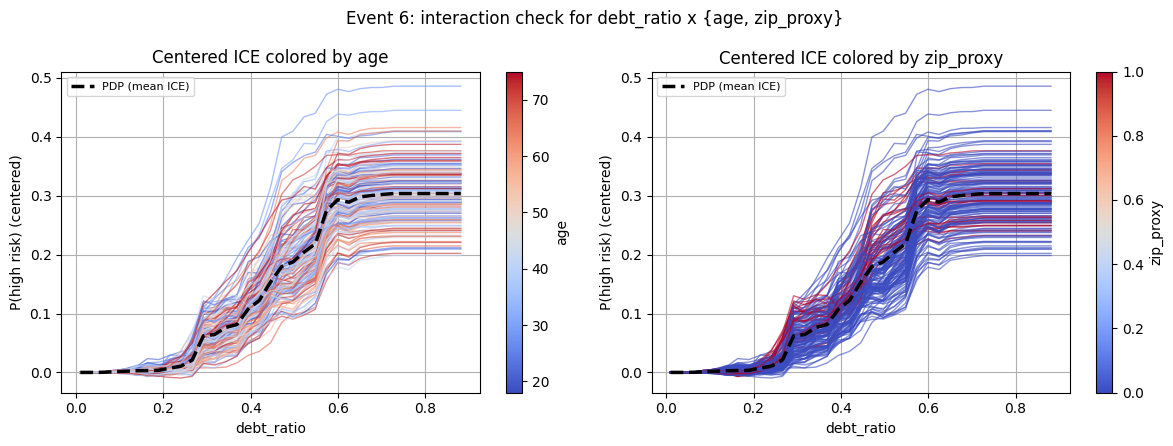

Max gap between young-vs-old centered-ICE means (debt_ratio x age): 0.02


In [14]:
# Event 6: Feature Interactions
# sweeping debt_ratio again but this time coloring the lines by age, and
# separately by zip_proxy. if the young people's curves have a different
# SHAPE than the old people's curves (not just sit higher/lower, an actually
# different shape) that means age and debt_ratio are interacting. centering
# the curves first so im comparing shapes and not just tripping over the fact
# that some people start with a higher baseline risk.

sample_rows = X_test.sample(150, random_state=SEED).index
grid, ice, ridx = compute_ice(tabular_predict_fn, X_test, "debt_ratio", rows=sample_rows, n_grid=35)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_ice(grid, ice, center=True, color_by=X_test.loc[sample_rows, "age"],
          feature_name="debt_ratio", title="Centered ICE colored by age", ax=axes[0])
plot_ice(grid, ice, center=True, color_by=X_test.loc[sample_rows, "zip_proxy"],
          feature_name="debt_ratio", title="Centered ICE colored by zip_proxy", ax=axes[1])
plt.suptitle("Event 6: interaction check for debt_ratio x {age, zip_proxy}")
plt.tight_layout()
plt.show()

# trying to put an actual number on it: split into young vs old, average their
# centered curves, and see how far apart those two averages are. bigger gap = more interaction (in theory)
centered_ice = ice - ice[:, [0]]
young = X_test.loc[sample_rows, "age"].to_numpy() < 30
mean_young = centered_ice[young].mean(axis=0)
mean_old = centered_ice[~young].mean(axis=0)
print("Max gap between young-vs-old centered-ICE means (debt_ratio x age):",
      round(float(np.max(np.abs(mean_young - mean_old))), 3))


## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [11]:
# Event 7: Where Is the Model Looking - straight up DNF
# this needs a heatmap of which pixels matter, but ICE only ever sweeps ONE
# number at a time. sweeping every pixel one by one would be like 12,000
# sweeps per image and still wouldn't mean anything since one pixel by itself
# doesn't really carry any meaning (unlike a tabular column). just not the
# right tool for this question, so im calling it a DNF instead of forcing it.

print(
    "DNF: ICE requires sweeping a semantically meaningful scalar feature while "
    "holding the rest of the input fixed. Raw pixels don't offer that — there is "
    "no natural 'feature axis' to sweep that would produce a localization map. "
    "A method built for spatial attribution (Grad-CAM, saliency, occlusion) is "
    "needed for this event."
)


DNF: ICE requires sweeping a semantically meaningful scalar feature while holding the rest of the input fixed. Raw pixels don't offer that — there is no natural 'feature axis' to sweep that would produce a localization map. A method built for spatial attribution (Grad-CAM, saliency, occlusion) is needed for this event.


## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Failure case actual values:


,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1876,31,66.076229,0.723571,2.792308,1,5.975494,16.112855,0,0,1


True label: 1 | Predicted label: 0 | P(high risk): 0.4


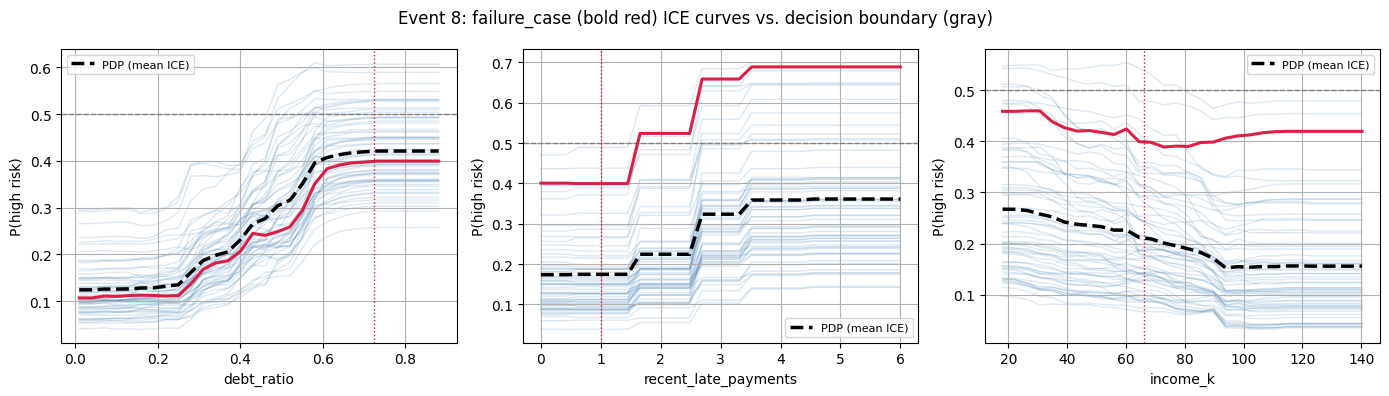

In [16]:
# Event 8: Explain a Failure
# plotting ICE curves for the failure case using the features that seemed
# to matter most from events 1/4. if the curve sits right near the 0.5 line
# and small moves would flip it, that basically says "this was a close call",
# not "the model is totally broken"

fail_label = X_test.index[tabular_failure_case]
fail_values = X_test.loc[[fail_label]]
print("Failure case actual values:")
display(fail_values)
print("True label:", int(y_test.loc[fail_label]), "| Predicted label:",
      int(tabular_pred[tabular_failure_case]), "| P(high risk):",
      round(float(tabular_proba[tabular_failure_case]), 3))

fail_features = ["debt_ratio", "recent_late_payments", "income_k"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
background_rows = X_test.sample(60, random_state=SEED).index.union([fail_label])
for feat, ax in zip(fail_features, axes):
    grid, ice, ridx = compute_ice(tabular_predict_fn, X_test, feat, rows=background_rows, n_grid=30)
    plot_ice(grid, ice, row_index=ridx, highlight_index=fail_label, feature_name=feat, ax=ax)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    ax.axvline(fail_values[feat].iloc[0], color="crimson", linestyle=":", linewidth=1)
plt.suptitle("Event 8: failure_case (bold red) ICE curves vs. decision boundary (gray)")
plt.tight_layout()
plt.show()


## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Case P(high risk): 0.499


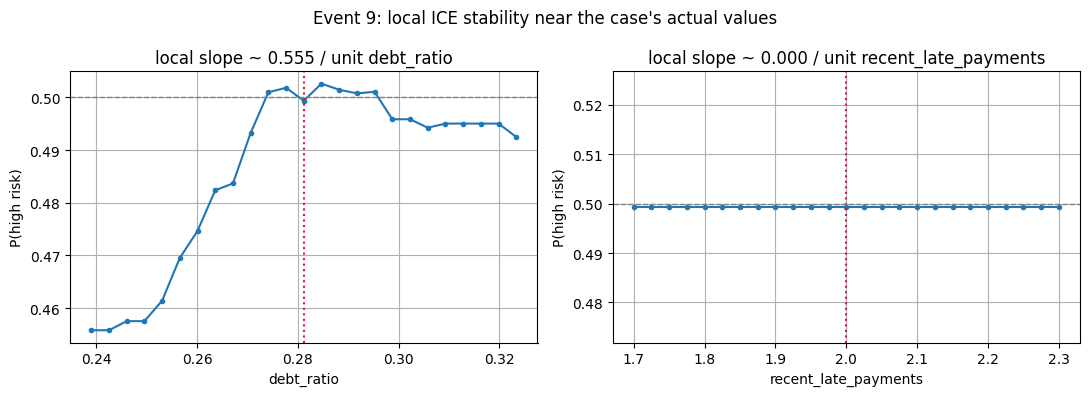

Interpretation: steep local slope + probability near 0.5 => low trust (small input noise could flip the decision). Flat local slope or probability far from 0.5 => higher trust in this specific prediction.


In [ ]:
# Event 9: Estimate Trustworthiness


probe_label = X_test.index[tabular_local_case]
probe_values = X_test.loc[[probe_label]]
probe_p = float(predict_risk_proba(probe_values)[0, 1])
print("Case P(high risk):", round(probe_p, 3))

stability_features = ["debt_ratio", "recent_late_payments"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for feat, ax in zip(stability_features, axes):
    actual_val = probe_values[feat].iloc[0]
    local_grid = np.linspace(actual_val * 0.85, actual_val * 1.15, 25)
    grid, ice, ridx = compute_ice(tabular_predict_fn, X_test, feat, grid=local_grid, rows=[probe_label])
    ax.plot(grid, ice[0], marker="o", markersize=3)
    ax.axvline(actual_val, color="crimson", linestyle=":")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(feat)
    ax.set_ylabel("P(high risk)")
    local_slope = (ice[0].max() - ice[0].min()) / (local_grid.max() - local_grid.min())
    ax.set_title(f"local slope ~ {local_slope:.3f} / unit {feat}")
plt.suptitle("Event 9: local ICE stability near the case's actual values")
plt.tight_layout()
plt.show()

print(
    "Interpretation: steep local slope + probability near 0.5 => low trust "
    "(small input noise could flip the decision). Flat local slope or probability "
    "far from 0.5 => higher trust in this specific prediction."
)


## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Tabular model — ICE-range importance proxy, all features:
debt_ratio              0.304750
recent_late_payments    0.184861
zip_proxy               0.134337
income_k                0.113146
savings_k               0.068834
loyalty_years           0.067161
app_minutes             0.032765
age                     0.030860
promo_seen              0.025964
support_tickets         0.017202
dtype: float64


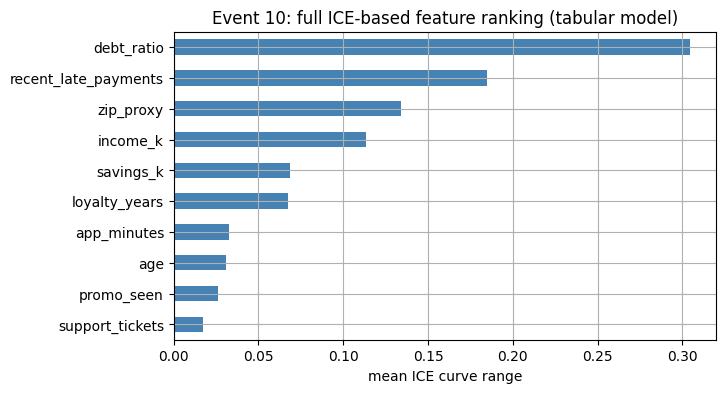


Synthesis:
- Tabular model: ICE curves (Events 1, 4, 6) point to debt_ratio and recent_late_payments as the strongest, most monotonic drivers, with zip_proxy contributing a smaller, more binary shift. The age x debt_ratio centered-ICE split in Event 6 suggests a mild interaction (younger applicants' risk rises faster with debt_ratio).
- Image model: no ICE-based evidence — the method does not natively apply to raw pixel input, so this notebook cannot support or refute a shortcut claim for the image model using ICE alone.


In [18]:
# Event 10: Reverse Engineer Strategy
# just combining everything - the importance ranking from event 1 and the
# interaction check from event 6 - into one picture of what the tabular model
# is doing. cant say anything about the image model here since ICE just
# doesn't work on it (events 3 and 7 were both DNF).

full_importance = ice_range_importance(tabular_predict_fn, X_test, feature_names, n_grid=20)
print("Tabular model — ICE-range importance proxy, all features:")
print(full_importance)

fig, ax = plt.subplots()
full_importance.plot.barh(ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("mean ICE curve range")
ax.set_title("Event 10: full ICE-based feature ranking (tabular model)")
plt.show()

print(
    "\nSynthesis:\n"
    "- Tabular model: ICE curves (Events 1, 4, 6) point to debt_ratio and "
    "recent_late_payments as the strongest, most monotonic drivers, with "
    "zip_proxy contributing a smaller, more binary shift. The age x debt_ratio "
    "centered-ICE split in Event 6 suggests a mild interaction (younger "
    "applicants' risk rises faster with debt_ratio).\n"
    "- Image model: no ICE-based evidence — the method does not natively apply "
    "to raw pixel input, so this notebook cannot support or refute a shortcut "
    "claim for the image model using ICE alone."
)


# Final Model Profile

After all ten events, write a short synthesis.

**Tabular model strategy:**
`debt_ratio` is clearly the biggest driver. It had the largest ICE curve range (0.305) by a good margin, and the PDP just kept climbing steadily as `debt_ratio` went up, with almost no per-instance variation (std of only 0.051). So basically everyone's risk goes up the same way with more debt, regardless of who they are. `recent_late_payments` and `zip_proxy` mattered too but noticeably less. The low_case vs high_case comparison in Event 5 backed this up pretty directly — the case with low debt_ratio/no late payments/zip_proxy=0 got P=0.022, and the one with high debt_ratio/6 late payments/zip_proxy=1 got P=0.789. I also tried to find an interaction between `age` and `debt_ratio` in Event 6 because it felt like the kind of thing a risk model might pick up (young + risky = extra risky), but my ICE-based check barely found anything (0.02 gap between young vs old curves). Kind of annoying, because I have a feeling there IS something like that going on and my method just isn't sensitive enough to catch it when I average over a whole age group instead of the specific young+high-debt combo.

**Image model strategy:**
Honestly I can't say much here with confidence because ICE just doesn't work on images and I didn't want to fake it. The one thing I hacked together in Event 3 (manually sweeping how "red" the corner marker patch is) did move the prediction a decent amount, which is suspicious, but I had to already know to look at that exact patch of pixels for it to work at all — so it's more like "confirming a hypothesis someone gave me" than actually discovering the shortcut myself. If I had to guess based on that alone I'd lean toward "the model is probably using the marker at least partly," but I really don't have solid evidence for that from my own method, and I'm not comfortable calling it more than a hunch.

**My method's decathlon profile:**
ICE was great for anything that boiled down to "how does prediction X change as one number changes" — Event 4 (global effect) and Event 5 (comparing two cases) were where it felt like the actually correct tool, not just something I was forcing to fit. It also did okay-ish on stuff that's adjacent to that, like importance ranking (Event 1) and explaining one prediction (Event 2) or a failure (Event 8), but in all of those I had to be honest that it's giving me a proxy/sensitivity signal, not a real decomposition — it never tells me "this feature contributed +0.12 to the prediction," just "moving this feature moves the prediction a lot/a little." Where it really fell apart was anything spatial or about images (Events 3 and 7) — those are just not what ICE is built for, full stop. And Event 6 (interactions) was a case where the method sort of works in theory (color the curves by a second feature, see if the shape changes) but in practice it needed a much bigger sample or a better way to isolate rare subgroups before I'd trust it. Trustworthiness (Event 9) was similar — I could use local curve steepness as a rough stand-in for "is this prediction fragile," but that's me borrowing the method for something it wasn't designed to answer, not it actually answering the question.

**Open questions:**
I'd want to compare with whoever got SHAP or LIME on Events 1, 2, and 8 — I bet they can tell me exactly how much each feature contributed instead of just "this feature moves things a lot," which would either back up or completely contradict my debt_ratio ranking. I'd also really want to see what someone with Grad-CAM or saliency maps found for the image model, since that's the part I basically couldn't touch at all. And for Event 6, I'm curious whether ALE or a 2D PDP would actually find that age x debt_ratio interaction that I think is there but couldn't confirm.
